In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel("/content/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


**Drop Null values from the column of CustomerID**

In [8]:
df.dropna(subset=['CustomerID'],inplace=True)

In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


**Create first day of purchase month**

In [10]:
import datetime as dt

In [11]:
def start_of_month(x):
  return dt.datetime(x.year,x.month,1)

In [12]:
df['InvoiceMonth']=df['InvoiceDate'].apply(start_of_month)

**when each customer first made a purchase**

In [15]:
df['CohortMonth']=df.groupby('CustomerID')['InvoiceMonth'].transform('min')

In [25]:
df.sample(10).iloc[:,-2:]

,InvoiceMonth,CohortMonth
409212,2011-10-01,2010-12-01
130679,2011-03-01,2010-12-01
454941,2011-11-01,2011-08-01
494417,2011-11-01,2011-08-01
79374,2011-02-01,2010-12-01
384193,2011-10-01,2010-12-01
290383,2011-08-01,2011-08-01
211490,2011-06-01,2011-06-01
417813,2011-10-01,2011-03-01
92107,2011-02-01,2011-01-01


**Calculate the cohort Index**

In [26]:
df['InvoiceMonth']=pd.to_datetime(df['InvoiceMonth'])
df['CohortMonth']=pd.to_datetime(df['CohortMonth'])

df['CohortIndex']=(df['InvoiceMonth'].dt.year-df['CohortMonth'].dt.year)*12+\
 (df['InvoiceMonth'].dt.month-df['CohortMonth'].dt.month)+1

In [28]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
63622,541585,22854,CREAM SWEETHEART EGG HOLDER,4,2011-01-19 14:22:00,4.95,14180.0,United Kingdom,2011-01-01,2010-12-01,2
532795,580997,23302,KNEELING MAT HOUSEWORK DESIGN,6,2011-12-06 17:23:00,0.79,15023.0,United Kingdom,2011-12-01,2010-12-01,13
373617,569336,47566,PARTY BUNTING,8,2011-10-03 14:05:00,4.95,15088.0,United Kingdom,2011-10-01,2011-10-01,1
216995,555865,22470,HEART OF WICKER LARGE,4,2011-06-07 14:30:00,2.95,14530.0,United Kingdom,2011-06-01,2011-02-01,5
75856,542612,21485,RETROSPOT HEART HOT WATER BOTTLE,2,2011-01-30 14:19:00,4.95,17841.0,United Kingdom,2011-01-01,2010-12-01,2
2119,536560,22652,TRAVEL SEWING KIT,10,2010-12-01 15:00:00,1.65,13093.0,United Kingdom,2010-12-01,2010-12-01,1
440314,574530,23482,PEARLISED IVORY HEART LARGE,4,2011-11-04 14:07:00,1.65,16887.0,United Kingdom,2011-11-01,2011-11-01,1
530405,580865,23390,DOLLY GIRL MINI BACKPACK,1,2011-12-06 11:58:00,4.15,17914.0,United Kingdom,2011-12-01,2011-12-01,1
38420,C539569,22923,FRIDGE MAGNETS LES ENFANTS ASSORTED,-13,2010-12-20 12:01:00,0.85,17204.0,United Kingdom,2010-12-01,2010-12-01,1
447737,574960,23582,VINTAGE DOILY JUMBO BAG RED,10,2011-11-08 10:17:00,2.08,17091.0,United Kingdom,2011-11-01,2010-12-01,12


**#count the customer ID by grouping by Cohort Month  and Cohort Index**

In [32]:
cohort_df=df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_df.rename(columns={'CustomerID': 'Customer Count'}, inplace=True)
cohort_df

,CohortMonth,CohortIndex,Customer Count
0,2010-12-01,1,948
1,2010-12-01,2,362
2,2010-12-01,3,317
3,2010-12-01,4,367
4,2010-12-01,5,341
...,...,...,...
86,2011-10-01,2,93
87,2011-10-01,3,46
88,2011-11-01,1,321
89,2011-11-01,2,43


***Pivot Table**

In [33]:
cohort_table=cohort_df.pivot(index='CohortMonth',columns='CohortIndex',values='Customer Count')
cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02-01,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03-01,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04-01,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05-01,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here:

Each row is a cohort (month when customers first purchased).

Each column (1, 2, 3, …) is how many months since that cohort started.

The numbers (Customer Count) are unique users active in that period.

In [36]:
cohort_size=cohort_table.iloc[:,0]
retention_table=cohort_table.divide(cohort_size,axis=0)

In [37]:
retention_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.381857,0.334388,0.387131,0.359705,0.396624,0.379747,0.354430,0.354430,0.394515,0.373418,0.500000,0.274262
2011-01-01,1.0,0.239905,0.282660,0.242280,0.327791,0.299287,0.261283,0.256532,0.311164,0.346793,0.368171,0.149644,NaN
2011-02-01,1.0,0.247368,0.192105,0.278947,0.268421,0.247368,0.255263,0.281579,0.257895,0.313158,0.092105,NaN,NaN
2011-03-01,1.0,0.190909,0.254545,0.218182,0.231818,0.177273,0.263636,0.238636,0.288636,0.088636,NaN,NaN,NaN
2011-04-01,1.0,0.227425,0.220736,0.210702,0.207358,0.237458,0.230769,0.260870,0.083612,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.236559,0.172043,0.172043,0.215054,0.243728,0.265233,0.103943,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.208511,0.187234,0.272340,0.246809,0.336170,0.102128,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.209424,0.204188,0.230366,0.272251,0.115183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.251497,0.251497,0.251497,0.137725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
retention_table.index=retention_table.index.strftime("%B %Y")

<Axes: xlabel='CohortIndex', ylabel='CohortMonth'>

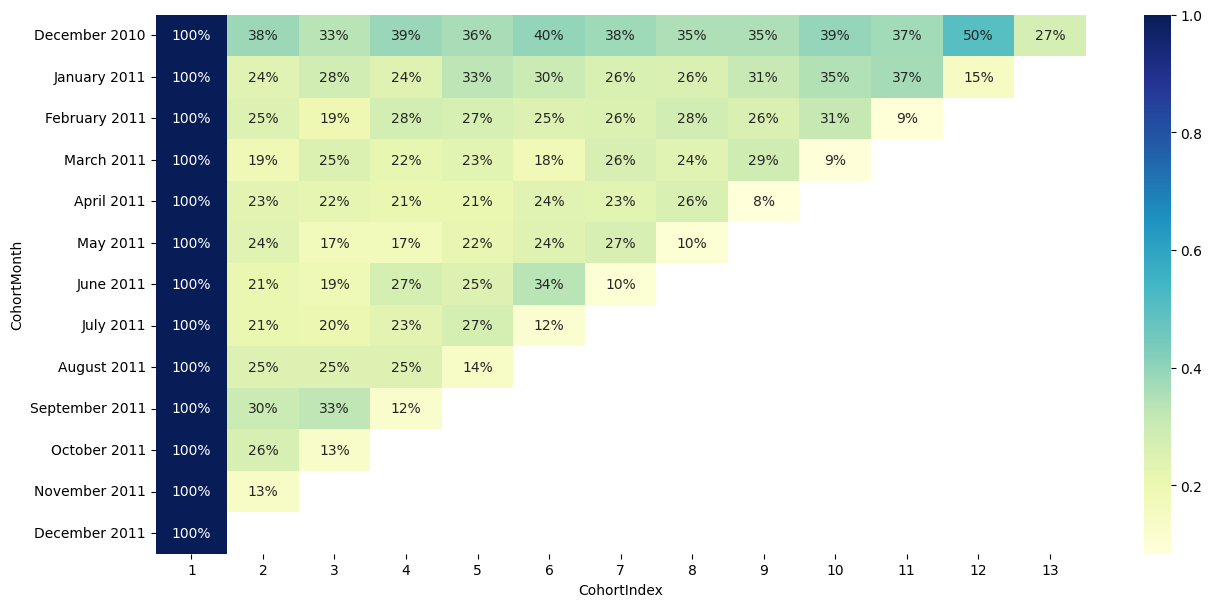

In [46]:
plt.figure(figsize=(15,7))
sns.heatmap(retention_table,annot=True,cmap="YlGnBu",fmt='.0%')